# Riemannian Flow Matching on the Stiefel Manifold

This interactive tutorial demonstrates how to train a continuous-time Flow Matching model to synthesize distributions on the **Stiefel Manifold** $St(n, p)$.

The Stiefel Manifold is the set of all $n \times p$ matrices with orthonormal columns, satisfying $U^T U = I_p$. Our goal is to train a vector field that transports a random uniform manifold distribution into a highly structured target mixture of distributions.


In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
    
print("Using device:", device)

Using device: mps


## 1. Stiefel Geometry Backend
To do calculations on the manifold we require the canonical metric $\langle D_1, D_2\rangle_U$ alongside exponential/logarithmic maps! The following blocks implement these algorithms.


In [2]:
def Stiefel_Exp(U0, Delta):
    """
    Computes U1 = Exp^{St}_U0(Delta)
    """
    n, p = U0.shape
    A = U0.T @ Delta
    K = Delta - U0 @ A
    
    QE, Re = la.qr(K, overwrite_a=True, mode='economic', check_finite=False)

    upper = np.concatenate((A, -Re.T), axis=1)
    lower = np.concatenate((Re, np.zeros((p, p), dtype=Re.dtype)), axis=1)
    L = np.concatenate((upper, lower), axis=0)
    MNe = la.expm(L)
    MNe = MNe[:, 0:p]

    U1 = U0 @ MNe[0:p, 0:p] + QE @ MNe[p:2*p, 0:p]
    return U1

def Stiefel_Log_alg(U0, U1, tau, do_Procrustes=0):
    """
    Computes Delta = Log^{St}_U0(U1), up to an accuracy of tau.
    """
    n, p = U0.shape
    
    check_det = 1
    M = U0.T @ U1
    U0orth = U1 - U0 @ M 
    Q, N = la.qr(U0orth, overwrite_a=True, mode='economic', check_finite=False)
    MN = np.concatenate((M, N), axis=0)    
    V, Rq = la.qr(MN, overwrite_a=True, mode='full', check_finite=False)

    if do_Procrustes:
        D, S, R = la.svd(V[p:2*p, p:2*p], full_matrices=False, compute_uv=True, overwrite_a=False)
        R = R.T
        V[:, p:2*p] = V[:, p:2*p] @ (R @ D.T)
        
    V = np.concatenate((MN, V[:, p:2*p]), axis=1)
    
    if check_det:
        if do_Procrustes:
            if np.power(-1, p) * np.prod(np.diag(Rq[:p, :p])) * np.linalg.det(R @ D.T) < 0:
                V[:, p] = -1 * V[:, p]
        else:
            if np.power(-1, p) * np.prod(np.diag(Rq[:p, :p])) < 0:
                V[:, p] = -1 * V[:, p]
             
    conv_hist = []                                                     
    for k in range(1000):
        LV = la.logm(V)
        np.fill_diagonal(LV, 0.0)
        LV = np.real(0.5 * (LV - LV.T))
        
        C = LV[p:2*p, p:2*p]      
 
        normC = la.norm(C, 'fro')
        conv_hist.append(normC)
        if normC < tau:
            break
        
        Phi = la.expm(-C)
        V[:, p:2*p] = V[:, p:2*p] @ Phi   
  
    Delta = U0 @ LV[0:p, 0:p] + Q @ LV[p:2*p, 0:p]
    return Delta, conv_hist

## 1.1 Geometry Bounds Checking (Exp / Log)

We can prove our geometry maps correctly construct perfectly reversible geodesic paths acting upon the manifold. We will pick two specific points $U_0$ and $U_1$, capture their exact geometrical `Log` boundaries, and compute linear scale geodesic projections iteratively mapping tracking errors along intermediate steps $t \in [0, 1]$.


MSE Error between target U1 and matched geometry map Exp(U0, Log(U0, U1)): 1.2454e-32


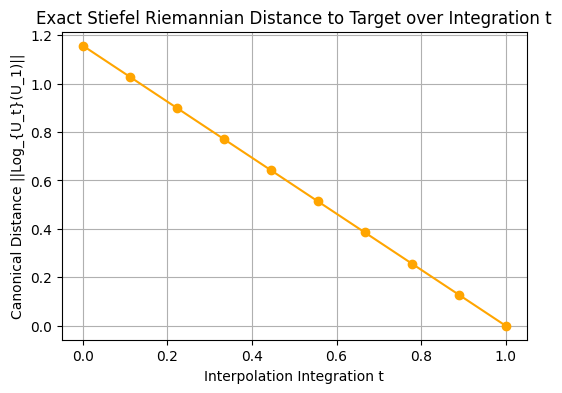

In [3]:
def riemannian_dist(U, V):
    D, _ = Stiefel_Log_alg(U, V, 1e-4)
    # canonical inner product norm computation
    a1 = np.trace(D.T @ D)
    a2 = np.trace((D.T @ U) @ (U.T @ D))
    return np.sqrt(max(a1 - 0.5 * a2, 0))

# Sample two distinct Stiefel matrices
np.random.seed(42)
n, p = 3, 2
G0, G1 = np.random.randn(n, p), np.random.randn(n, p)
Q0, R0 = la.qr(G0, mode='economic'); U0 = Q0 @ np.diag(np.sign(np.diag(R0)))
Q1, R1 = la.qr(G1, mode='economic'); U1 = Q1 @ np.diag(np.sign(np.diag(R1)))

# Log gives the orthogonal Tangent space offset Delta from U0 -> U1
Delta, _ = Stiefel_Log_alg(U0, U1, 1e-4)

# Exp wraps Delta mapped back expanding out starting from U0
U1_approx = Stiefel_Exp(U0, Delta)
print(f"MSE Error between target U1 and matched geometry map Exp(U0, Log(U0, U1)): {np.mean((U1 - U1_approx)**2):.4e}")

t_vals = np.linspace(0, 1, 10)
distances = []

for t in t_vals:
    # Scale tangent projection
    U_t = Stiefel_Exp(U0, t * Delta)
    dist = riemannian_dist(U_t, U1)
    distances.append(dist)

plt.figure(figsize=(6, 4))
plt.plot(t_vals, distances, marker='o', c='orange')
plt.title("Exact Stiefel Riemannian Distance to Target over Integration t")
plt.xlabel("Interpolation Integration t")
plt.ylabel("Canonical Distance ||Log_{U_t}(U_1)||")
plt.grid(True)
plt.show()

## 2. Riemann & Flow Matching Math Setup

Flow Matching hinges on having a base metric to calculate loss and trajectory paths. We use the **canonical metric**. Rather than forcing the neural network to output explicit geodesics iteratively via the heavy Stiefel `Log` algorithm, we **precalculate** targets and solve paths analytically forward as an Initial Value Problem using Edelman's matrix exponential representation.


In [4]:
def canonical_metric_torch(D1, D2, U):
    """
    Computes batched canonical Riemannian metric for Stiefel manifold.
    <D1, D2>_U = tr(D1^T D2) - 0.5 * tr((D1^T U) (U^T D2))
    """
    a1 = torch.einsum('bji,bjk->bik', D1, D2) 
    a1_tr = torch.diagonal(a1, dim1=-2, dim2=-1).sum(-1)
    
    part1 = torch.einsum('bji,bjk->bik', D1, U)
    part2 = torch.einsum('bji,bjk->bik', U, D2)
    a2_mat = torch.einsum('bij,bjk->bik', part1, part2)
    a2_tr = torch.diagonal(a2_mat, dim1=-2, dim2=-1).sum(-1)
    
    return a1_tr - 0.5 * a2_tr

def get_geodesic_and_velocity(U0, Delta, t):
    """
    Constructs the exact geodesic Exp_U0(t * Delta) and its velocity derivative analytically!
    """
    n, p = U0.shape
    A = U0.T @ Delta
    K = Delta - U0 @ A
    QE, Re = la.qr(K, overwrite_a=False, mode='economic', check_finite=False)
    
    upper = np.concatenate((A, -Re.T), axis=1)
    lower = np.concatenate((Re, np.zeros((p, p), dtype=Re.dtype)), axis=1)
    L = np.concatenate((upper, lower), axis=0)
    
    MNe = la.expm(t * L)
    MNe_p = MNe[:, 0:p]
    
    # Path
    U_t = U0 @ MNe_p[0:p, :] + QE @ MNe_p[p:2*p, :]
    
    # Velocity field (derivative of exponential)
    dMNe = L @ MNe_p
    V_t = U0 @ dMNe[0:p, :] + QE @ dMNe[p:2*p, :]
    
    return U_t, V_t

## 3. Modeling the Vector Field

Our model predicts the target velocity `V_t`.
Crucially, any predicted velocity $Z \in \mathbb{R}^{n \times p}$ must geometrically belong to the tangent space $\mathcal{T}_U St(n, p)$. We can orthogonally project the network's unconstrained output back onto the constrained manifold using the projection form:
$$P_U(Z) = Z - U \cdot \text{sym}(U^T Z)$$


In [5]:
class StiefelVectorField(nn.Module):
    def __init__(self, n, p, hidden_dim=256):
        super().__init__()
        self.n, self.p = n, p
        
        self.time_mlp = nn.Sequential(nn.Linear(1, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.U_mlp = nn.Sequential(nn.Linear(n * p, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2), nn.SiLU(),
            nn.Linear(hidden_dim * 2, hidden_dim * 2), nn.SiLU(),
            nn.Linear(hidden_dim * 2, n * p)
        )
    
    def forward(self, t, U):
        B = U.shape[0]
        if t.shape[0] == 1:
            t = t.expand(B, 1)
            
        Z_flat = self.net(self.time_mlp(t) + self.U_mlp(U.view(B, -1)))
        Z = Z_flat.view(B, self.n, self.p) # Raw output
        
        # Project Z onto the tangent space T_U St(n, p) ensures geometrically safe outputs
        UtZ = torch.einsum('bji,bjk->bik', U, Z)
        sym_UtZ = 0.5 * (UtZ + UtZ.transpose(1, 2))
        return Z - torch.einsum('bij,bjk->bik', U, sym_UtZ)

## 4. Gaussian Dataset Precomputation
Our target distribution is like a mixture of two Gaussians. We pick two points on the Stiefel manifold, and these points are centers of projected-Gaussian distributions, formed by adding Gaussian noise and QR-projecting them back to $St(n,p)$. Because computing manifold Logs natively is expensive during training, we pre-bake a 1000-sample trajectory pool upfront.

In [6]:
def sample_uniform(B, n, p):
    U_list = []
    for _ in range(B):
        G = np.random.randn(n, p)
        Q, R = la.qr(G, mode='economic')
        Q = Q @ np.diag(np.sign(np.diag(R)))
        U_list.append(Q)
    return np.stack(U_list)

def create_target_mixture(B, n, p, noise_scale=0.15):
    np.random.seed(42)  # Fix seed for centers
    centers = sample_uniform(2, n, p)
    np.random.seed()
    
    U_list, labels = [], []
    for _ in range(B):
        idx = np.random.randint(0, 2)
        base = centers[idx]
        
        # Add gaussian noise and project back to Stiefel via QR
        noisy = base + np.random.randn(n, p) * noise_scale
        Q, R = la.qr(noisy, mode='economic')
        Q = Q @ np.diag(np.sign(np.diag(R)))
        
        U_list.append(Q)
        labels.append(idx)
    return np.stack(U_list), centers, labels

def precompute_dataset(n, p, num_samples=1024):
    print(f"Precomputing dataset of {num_samples} samples...")
    U0_all = sample_uniform(num_samples, n, p)
    U1_all, centers, labels = create_target_mixture(num_samples, n, p)
    
    Delta_all = []
    print("Computing log maps (this takes ~a few seconds depending on hw)...")
    for i in tqdm(range(num_samples), desc="BVP Log Solver"):
        # Riemannian boundary solver!
        Delta, _ = Stiefel_Log_alg(U0_all[i], U1_all[i], 1e-4)
        Delta_all.append(Delta)
        U1_all[i] = Stiefel_Exp(U0_all[i], Delta)
        
    return U0_all, np.stack(Delta_all), U1_all, centers, labels

n, p = 3, 2
U0_data, Delta_data, U1_data, centers, labels = precompute_dataset(n, p, num_samples=1024)
num_samples = len(U0_data)

Precomputing dataset of 1024 samples...
Computing log maps (this takes ~a few seconds depending on hw)...


BVP Log Solver:   0%|          | 0/1024 [00:00<?, ?it/s]

### 4.1 Target Distribution Visualization
Before training, let's take a look at what the generated target Stiefel distribution looks like. On $St(3, 2)$, each matrix has columns representing 3 clustered points on a plane. The mixture shows the noisy distribution strictly wrapped around our two explicit center layouts (denoted by stars and crosses).


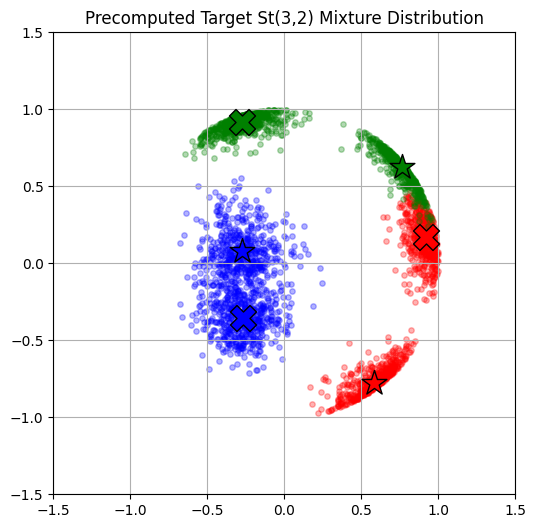

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.grid(True)
ax.set_title("Precomputed Target St(3,2) Mixture Distribution")

colors = ['r', 'g', 'b'] 
marker_styles = ['*', 'X'] 

# Plot true distinct centers
for i, center in enumerate(centers):
    for j in range(3):
        ax.scatter(center[j, 0], center[j, 1], marker=marker_styles[i], color=colors[j], s=350, edgecolor='k', zorder=10)

# Plot randomly sampled manifold targets
for j in range(3):
    ax.scatter(U1_data[:, j, 0], U1_data[:, j, 1], color=colors[j], alpha=0.3, s=15)
    
plt.show()

## 5. Main Training Loop
We compile the dataset mapped along random $t_{batch}$ and then fit the predicted vector fields against the precomputed deterministic trajectory bounds using MSE wrapped inside the canonical inner metric structure.


Starting Training...


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Finished!


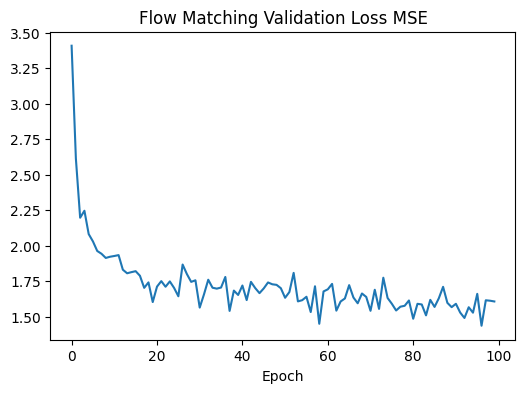

In [8]:
epochs = 100
batch_size = 64

# Init Model
model = StiefelVectorField(n, p).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

loss_history = []
print("Starting Training...")

for epoch in tqdm(range(epochs), desc="Epochs"):
    model.train()
    indices = np.random.permutation(num_samples)
    epoch_loss = 0.0
    
    for batch_start in range(0, num_samples, batch_size):
        batch_idx = indices[batch_start:batch_start + batch_size]
        B = len(batch_idx)

        t_batch = np.random.rand(B)
        Ut_np, Vt_np = np.zeros((B, n, p)), np.zeros((B, n, p))
        for i in range(B):
            u, v = get_geodesic_and_velocity(U0_data[batch_idx[i]], Delta_data[batch_idx[i]], t_batch[i])
            Ut_np[i], Vt_np[i] = u, v
            
        t_tensor = torch.tensor(t_batch, dtype=torch.float32).unsqueeze(1).to(device)
        Ut_tensor = torch.tensor(Ut_np, dtype=torch.float32).to(device)
        Vt_tensor = torch.tensor(Vt_np, dtype=torch.float32).to(device)
        
        optimizer.zero_grad()
        V_pred = model(t_tensor, Ut_tensor)
        
        # Loss minimization enforcing alignment of fields within the geometry
        diff = V_pred - Vt_tensor
        loss = canonical_metric_torch(diff, diff, Ut_tensor).mean()
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * B
        
    loss_history.append(epoch_loss / num_samples)
print("Finished!")

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title("Flow Matching Validation Loss MSE")
plt.xlabel("Epoch")
plt.show()

## 6. Evaluation and Visualization Subroutines
We integrate smoothly using Euler solving over the vector field. By decomposing $St(3, 2)$ column representations into 2D plots we can neatly trace convergence trajectories across the manifold dynamically!


In [9]:
from IPython.display import HTML

def animate_trajectories(model, U0_val, U1_val, centers, labels, n, p, name="assets/outputs_tutorial.gif"):
    if n != 3 or p != 2:
        print("Skipping animation: n, p must be 3, 2 for 2D visualization.")
        return
        
    model.eval()
    t_vals = np.linspace(0, 1, 100)
    num_test = min(30, U0_val.shape[0])
    B = num_test
    dt = 1.0 / (len(t_vals) - 1)
    
    U_traj = [U0_val[:num_test]]
    U_curr = U0_val[:num_test]
    
    # ODE Euler Solver Path rollout
    with torch.no_grad():
        for t in t_vals[:-1]:
            t_tensor = torch.full((B, 1), t, dtype=torch.float32).to(device)
            U_tensor = torch.tensor(U_curr, dtype=torch.float32).to(device)
            V_pred = model(t_tensor, U_tensor).cpu().numpy()
            
            U_next = np.stack([Stiefel_Exp(U_curr[i], V_pred[i] * dt) for i in range(B)])
            U_curr = U_next
            U_traj.append(U_curr)

    U_traj = np.array(U_traj)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_title("Riemannian Flow Matching Trajectories - St(3,2)")
    
    colors = ['r', 'g', 'b'] 
    marker_styles = ['*', 'X'] 
    for i, center in enumerate(centers):
        for j in range(3):
            ax.scatter(center[j, 0], center[j, 1], marker=marker_styles[i], color=colors[j], s=250, edgecolor='k', zorder=10)
    
    scatters = [ax.scatter([], [], color=colors[j], alpha=0.6, s=30) for j in range(3)]
        
    def update(frame):
        for j in range(3):
            scatters[j].set_offsets(U_traj[frame, :, j, :])
        return scatters
        
    ani = animation.FuncAnimation(fig, update, frames=U_traj.shape[0], interval=50, blit=True)
    ani.save(name, writer='pillow', fps=20)
    plt.close(fig)
    print(f"Saved {name}")
    return HTML(f"<img src='{name}'>")

# Inference and Export
print("Animating the trajectories...")
animate_trajectories(model, U0_data[:40], U1_data[:40], centers, labels[:40], n, p, "outputs_tutorial.gif")

Animating the trajectories...
Saved outputs_tutorial.gif
